In [18]:
"""
Clusterwise Jaccard stability for marker-gene tables.

Assumes each input dataframe looks like your example:
    - a gene identifier column (e.g. 'Unnamed: 0', or already the index)
    - an 'importance' column
    - one column per cluster/cell type, where a non-NaN value means
      "this gene is a marker (has a value) for this cluster" and NaN
      means "not a marker for this cluster in this run"

The function treats each dataframe as one "run" (e.g. a different
resolution, subsample, random seed, etc.), builds the set of marker
genes per cluster in each run, and computes the pairwise Jaccard index
of those gene sets across all pairs of runs, per cluster. The mean
(and std/min/max) of those pairwise Jaccard scores is the "stability"
of that cluster's marker-gene set across runs.
"""

from itertools import combinations
import numpy as np
import pandas as pd


def _get_gene_indexed_df(df, gene_col=None):
    """Return a copy of df indexed by gene name."""
    if gene_col is not None:
        return df.set_index(gene_col)
    if 'Unnamed: 0' in df.columns:
        return df.set_index('Unnamed: 0')
    # already indexed by gene, or no obvious gene column -> assume index is genes
    return df


def adata_to_marker_df(adata, groupby, groups=None, method='wilcoxon',
                        n_genes=20, pval_cutoff=0.05, logfc_cutoff=None,
                        use_raw=None, layer=None, value='scores',
                        key_added='rank_genes_groups'):
    """
    Run scanpy's rank_genes_groups on one AnnData object and reshape
    the result into the same gene x cluster table format used by
    clusterwise_jaccard_stability / the plotting functions above:
    one row per gene, one column per cluster, value = score (or
    whatever `value` you pick) if that gene is a marker for that
    cluster, NaN otherwise.

    Requires scanpy (pip install scanpy).

    Parameters
    ----------
    adata : AnnData
    groupby : str
        obs column with cluster/cell-type labels. Must use the same
        categories across all AnnData objects you plan to compare.
    groups : list of str, optional
        Subset of clusters to test (passed to rank_genes_groups).
        Defaults to all groups in `groupby`.
    method : str
        DE test method for rank_genes_groups (default 'wilcoxon').
    n_genes : int or None
        Keep at most this many top genes per cluster (by score) after
        filtering. Default 20. None keeps all genes passing the cutoffs.
    pval_cutoff : float or None
        Keep only genes with pvals_adj < pval_cutoff. None disables.
    logfc_cutoff : float or None
        Keep only genes with logfoldchanges > logfc_cutoff. None disables.
    use_raw, layer : passed through to sc.tl.rank_genes_groups.
    value : str
        Which rank_genes_groups column to use as the table's values
        ('scores', 'logfoldchanges', or 'pvals_adj'). Default 'scores'.
    key_added : str
        Key under adata.uns to store/read the rank_genes_groups result.

    Returns
    -------
    pd.DataFrame indexed by gene, one column per cluster.
    """
    import scanpy as sc

    sc.tl.rank_genes_groups(
        adata, groupby=groupby, groups=groups if groups is not None else 'all',
        method=method, use_raw=use_raw, layer=layer, key_added=key_added,
    )

    cluster_names = groups if groups is not None else list(
        adata.obs[groupby].astype('category').cat.categories
    )

    series_list = []
    for cluster in cluster_names:
        sub = sc.get.rank_genes_groups_df(adata, group=cluster, key=key_added)
        if pval_cutoff is not None and 'pvals_adj' in sub.columns:
            sub = sub[sub['pvals_adj'] < pval_cutoff]
        if logfc_cutoff is not None and 'logfoldchanges' in sub.columns:
            sub = sub[sub['logfoldchanges'] > logfc_cutoff]
        if n_genes is not None:
            sub = sub.head(n_genes)  # rank_genes_groups_df is score-sorted already

        s = sub.set_index('names')[value].rename(cluster)
        s = s[~s.index.duplicated()]  # guard against any dup gene names
        series_list.append(s)

    df = pd.concat(series_list, axis=1)  # outer join -> NaN where not a marker
    df.index.name = 'gene'
    return df


def adata_list_to_marker_dfs(adatas, groupby, **kwargs):
    """
    Convenience wrapper: run adata_to_marker_df on each AnnData in a
    list (e.g. several samples/runs/resolutions that share the same
    `groupby` categories), returning a list of dataframes ready to
    feed straight into clusterwise_jaccard_stability(...) and the
    plotting functions in this module.

    kwargs are forwarded to adata_to_marker_df (method, n_genes,
    pval_cutoff, logfc_cutoff, use_raw, layer, value, key_added).
    """
    return [adata_to_marker_df(ad, groupby, **kwargs) for ad in adatas]


def clusterwise_jaccard_stability(dfs, gene_col=None, exclude_cols=('importance',),
                                   cluster_cols=None):
    """
    Parameters
    ----------
    dfs : list of pd.DataFrame
        List of marker-gene tables (one per run), all sharing the same
        cluster/cell-type columns.
    gene_col : str, optional
        Name of the column holding gene names. If None, auto-detects
        'Unnamed: 0' or falls back to the existing index.
    exclude_cols : tuple of str
        Non-cluster columns to ignore (default: ('importance',)).
    cluster_cols : list of str, optional
        Explicit list of cluster columns to use. If None, uses the
        intersection of columns across all dfs (minus gene_col/exclude_cols).

    Returns
    -------
    pairwise_df : pd.DataFrame
        One row per (cluster, run_i, run_j) pair with the Jaccard index
        of the marker-gene sets for that cluster between those two runs.
    stability_summary : pd.DataFrame
        One row per cluster with mean/std/min/max/count of the pairwise
        Jaccard scores -> the overall stability of that cluster's markers.
    """
    dfs_indexed = [_get_gene_indexed_df(df, gene_col) for df in dfs]

    if cluster_cols is None:
        common_cols = set(dfs_indexed[0].columns)
        for df in dfs_indexed[1:]:
            common_cols &= set(df.columns)
        cluster_cols = sorted(common_cols - set(exclude_cols) - {gene_col})

    records = []
    for cluster in cluster_cols:
        # gene set (marker genes = non-NaN values) per run for this cluster
        gene_sets = []
        for df in dfs_indexed:
            if cluster in df.columns:
                genes = set(df.index[df[cluster].notna()])
            else:
                genes = set()
            gene_sets.append(genes)

        for i, j in combinations(range(len(gene_sets)), 2):
            a, b = gene_sets[i], gene_sets[j]
            if len(a) == 0 and len(b) == 0:
                jac = np.nan  # undefined, both empty
            else:
                jac = len(a & b) / len(a | b)
            records.append({
                'cluster': cluster,
                'run_i': i,
                'run_j': j,
                'n_genes_i': len(a),
                'n_genes_j': len(b),
                'n_shared': len(a & b),
                'jaccard': jac,
            })

    pairwise_df = pd.DataFrame(records)

    stability_summary = (
        pairwise_df.groupby('cluster')['jaccard']
        .agg(mean_jaccard='mean', std_jaccard='std', min_jaccard='min',
             max_jaccard='max', n_pairs='count')
        .reset_index()
        .sort_values('mean_jaccard', ascending=False)
    )

    return pairwise_df, stability_summary


def plot_cluster_jaccard_boxplot(pairwise_df, pal, order=None, ax=None,
                                  title='Clusterwise Jaccard stability',
                                  ylabel='Jaccard index', figsize=(8, 5),
                                  save_path=None):
    """
    Boxplot of per-cluster pairwise Jaccard scores, colored by a
    user-supplied cluster -> color palette.

    Parameters
    ----------
    pairwise_df : pd.DataFrame
        Output of clusterwise_jaccard_stability (must have 'cluster'
        and 'jaccard' columns).
    pal : dict
        Mapping of cluster name -> color (any matplotlib-recognized
        color spec, e.g. RGB tuples).
    order : list of str, optional
        Order of clusters on the x-axis. Defaults to descending mean
        jaccard.
    ax : matplotlib Axes, optional
        Axes to draw on. A new figure/axes is created if None.
    save_path : str, optional
        If given, saves the figure to this path (e.g. 'plot.png').

    Returns
    -------
    ax : matplotlib Axes
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    df = pairwise_df.dropna(subset=['jaccard']).copy()

    if order is None:
        order = (
            df.groupby('cluster')['jaccard'].mean()
            .sort_values(ascending=False).index.tolist()
        )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df, x='cluster', y='jaccard', order=order,
        palette=pal, hue='cluster', legend=False, ax=ax,
    )
    sns.stripplot(
        data=df, x='cluster', y='jaccard', order=order,
        color='black', size=3, alpha=0.5, jitter=True, ax=ax,
    )

    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    return ax


def _get_cluster_gene_sets(dfs_indexed, cluster, run_labels):
    """dict of run_label -> set of marker genes for one cluster."""
    contents = {}
    for label, df in zip(run_labels, dfs_indexed):
        if cluster in df.columns:
            genes = set(df.index[df[cluster].notna()])
        else:
            genes = set()
        contents[label] = genes
    return contents


def _upset_intersections(contents, run_order):
    """
    contents: dict run_label -> set of genes.
    Returns rows sorted by intersection size (desc), each row a dict
    with 'combo' (tuple of bools aligned to run_order), 'size', 'genes'.
    """
    all_genes = set().union(*contents.values()) if contents else set()
    combo_genes = {}
    for gene in all_genes:
        combo = tuple(gene in contents[r] for r in run_order)
        combo_genes.setdefault(combo, set()).add(gene)
    rows = [{'combo': combo, 'size': len(genes), 'genes': genes}
            for combo, genes in combo_genes.items()]
    rows.sort(key=lambda r: r['size'], reverse=True)
    return rows


def plot_cluster_upset(dfs, cluster, gene_col=None, run_labels=None,
                        color=None, min_subset_size=1, title=None,
                        figsize=None, save_path=None):
    """
    UpSet plot of marker-gene overlap across runs, for a single cluster:
    a bar chart of intersection sizes on top, and a dot/line matrix
    below showing which combination of runs each bar corresponds to.

    Self-contained (matplotlib only, no `upsetplot` dependency).

    Parameters
    ----------
    dfs : list of pd.DataFrame
        One marker-gene table per run (same format as
        clusterwise_jaccard_stability).
    cluster : str
        Cluster/cell-type column to plot.
    run_labels : list of str, optional
        Labels for each run/dataframe. Defaults to 'run0', 'run1', ...
    color : color, optional
        Single color for the bars/dots (e.g. from your pal dict for
        this cluster).
    min_subset_size : int
        Hide intersections smaller than this.
    save_path : str, optional
        If given, saves the figure to this path.

    Returns
    -------
    fig : matplotlib Figure
    """
    import matplotlib.pyplot as plt

    dfs_indexed = [_get_gene_indexed_df(df, gene_col) for df in dfs]
    if run_labels is None:
        run_labels = [f'run{i}' for i in range(len(dfs_indexed))]

    contents = _get_cluster_gene_sets(dfs_indexed, cluster, run_labels)
    rows = [r for r in _upset_intersections(contents, run_labels)
            if r['size'] >= min_subset_size]
    if not rows:
        rows = [{'combo': tuple(False for _ in run_labels), 'size': 0, 'genes': set()}]

    n_combos = len(rows)
    n_runs = len(run_labels)
    facecolor = color if color is not None else '#4C72B0'
    off_color = '#DADADA'

    if figsize is None:
        figsize = (max(4, 0.6 * n_combos + 2), 2.5 + 0.4 * n_runs)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2, 2, width_ratios=[1.2, n_combos], height_ratios=[2.2, max(1, n_runs)],
        wspace=0.05, hspace=0.08,
    )
    ax_bar = fig.add_subplot(gs[0, 1])
    ax_matrix = fig.add_subplot(gs[1, 1], sharex=ax_bar)
    ax_setsize = fig.add_subplot(gs[1, 0], sharey=ax_matrix)
    fig.add_subplot(gs[0, 0]).axis('off')  # empty corner

    # --- top: intersection-size bar chart ---
    sizes = [r['size'] for r in rows]
    x = list(range(n_combos))
    ax_bar.bar(x, sizes, color=facecolor, width=0.6)
    for xi, s in zip(x, sizes):
        ax_bar.text(xi, s, str(s), ha='center', va='bottom', fontsize=8)
    ax_bar.set_ylabel('Intersection size')
    ax_bar.spines[['top', 'right']].set_visible(False)
    ax_bar.tick_params(axis='x', bottom=False, labelbottom=False)

    # --- bottom: dot/line matrix ---
    for xi, row in enumerate(rows):
        combo = row['combo']
        present_idx = [i for i, v in enumerate(combo) if v]
        if len(present_idx) > 1:
            ax_matrix.plot([xi, xi], [min(present_idx), max(present_idx)],
                           color=facecolor, zorder=2, linewidth=2)
        for yi in range(n_runs):
            ax_matrix.scatter(
                xi, yi, s=90, zorder=3,
                color=facecolor if combo[yi] else off_color,
            )
    ax_matrix.set_yticks(range(n_runs))
    ax_matrix.set_ylim(-0.6, n_runs - 0.4)
    ax_matrix.invert_yaxis()
    ax_matrix.set_xlim(-0.6, n_combos - 0.4)
    ax_matrix.set_xticks([])
    ax_matrix.tick_params(axis='y', left=False, labelleft=False)
    for spine in ax_matrix.spines.values():
        spine.set_visible(False)

    # --- left: per-run total marker-gene set size (labels live here) ---
    set_sizes = [len(contents[r]) for r in run_labels]
    ax_setsize.barh(range(n_runs), set_sizes, color='#999999', height=0.6)
    ax_setsize.set_yticks(range(n_runs))
    ax_setsize.set_yticklabels(run_labels)
    ax_setsize.invert_xaxis()
    ax_setsize.set_xlabel('Set size')
    ax_setsize.tick_params(axis='y', left=False)
    ax_setsize.spines[['top', 'left']].set_visible(False)

    fig.suptitle(title or f'{cluster}: marker-gene overlap across runs')

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    return fig


def plot_all_cluster_upsets(dfs, pal, cluster_cols=None, gene_col=None,
                             run_labels=None, min_subset_size=1):
    """
    Convenience wrapper: makes one UpSet plot per cell type/cluster,
    colored using pal[cluster]. Returns the figures without saving
    anything to disk — display them yourself (e.g. plt.show() in a
    script, or just let them render in a notebook).

    Parameters
    ----------
    dfs : list of pd.DataFrame
    pal : dict
        cluster -> color, used both to pick which clusters to plot
        (if cluster_cols is None) and to color each cluster's plot.
    cluster_cols : list of str, optional
        Clusters to plot. Defaults to pal.keys().

    Returns
    -------
    dict of cluster -> matplotlib Figure
    """
    dfs_indexed = [_get_gene_indexed_df(df, gene_col) for df in dfs]
    if run_labels is None:
        run_labels = [f'run{i}' for i in range(len(dfs_indexed))]
    if cluster_cols is None:
        cluster_cols = list(pal.keys())

    figs = {}
    for cluster in cluster_cols:
        figs[cluster] = plot_cluster_upset(
            dfs_indexed, cluster, run_labels=run_labels,
            color=pal.get(cluster), min_subset_size=min_subset_size,
        )

    return figs




In [ ]:
pal = {
    'CD14+ Mono': (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
    'CD14- Mono': (0.6509803921568628, 0.807843137254902, 0.8901960784313725),
    'CD4+ T cell': (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
    'CD8+ T cell': (0.984313725490196, 0.6039215686274509, 0.6),
    'B cell': (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
    'NK cell': (1.0, 0.4980392156862745, 0.0),
    'pDC': (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
    'DC': (0.2, 0.6274509803921569, 0.17254901960784313),
}

In [13]:
mapper = {'cd14+_monocytes':  'CD14+ Mono',
 'nk_cells': 'NK cell', 
 'cd8+_tcells': 'CD8+ T cell', 
 'b_cells': 'B cell', 
 'cd14-_monocytes': 'CD14- Mono',
  'cd4+_tcells': 'CD4+ T cell',
  'pDC': 'pDC',
  'DC': 'DC'}

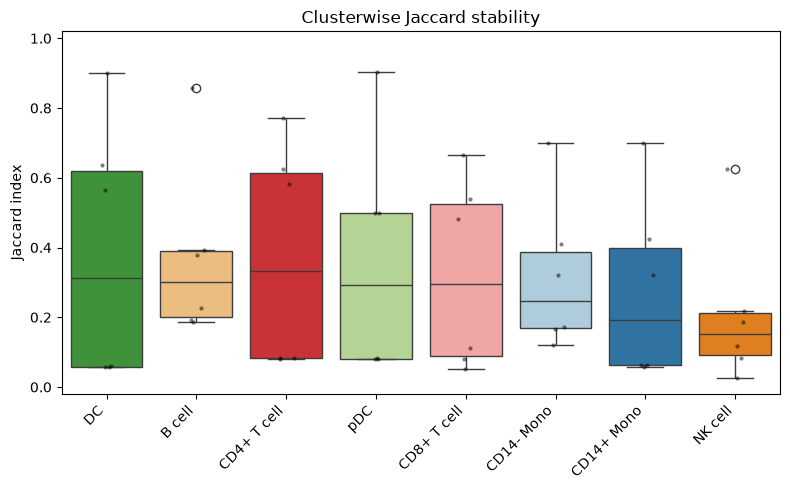

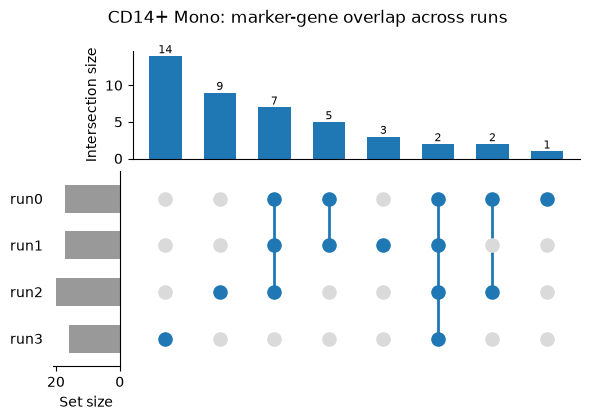

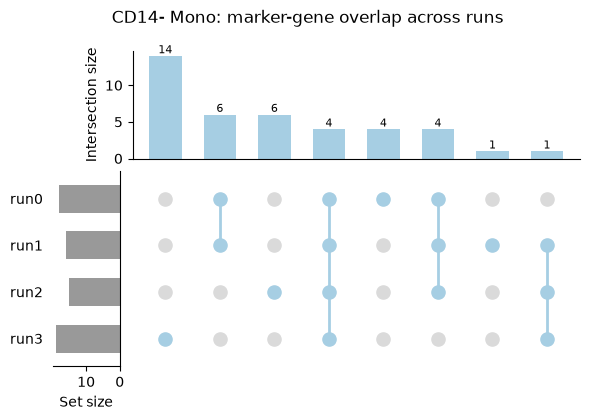

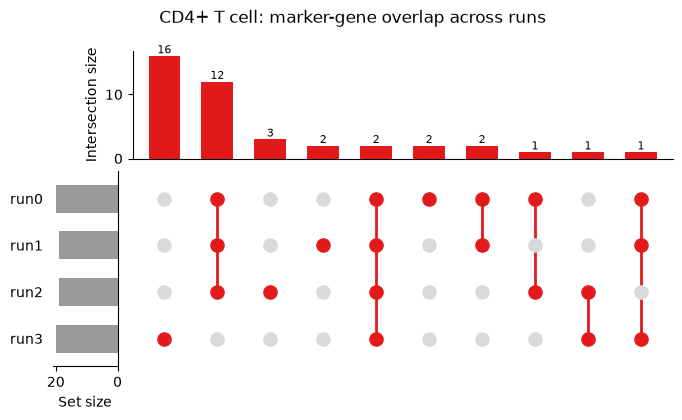

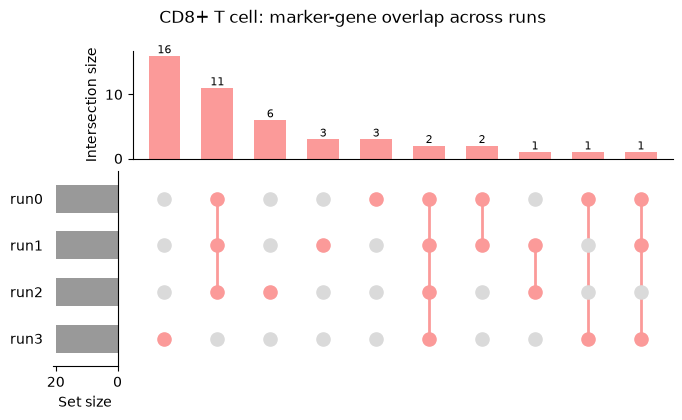

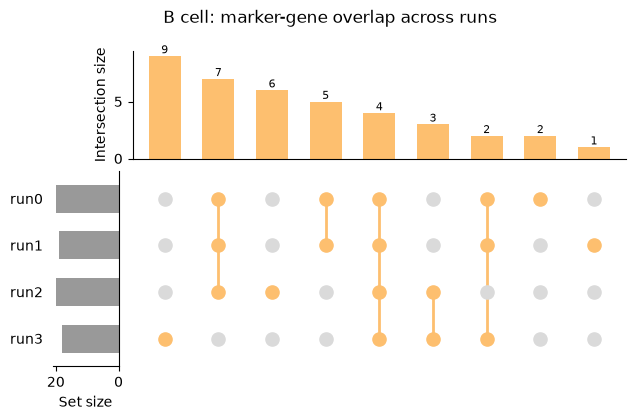

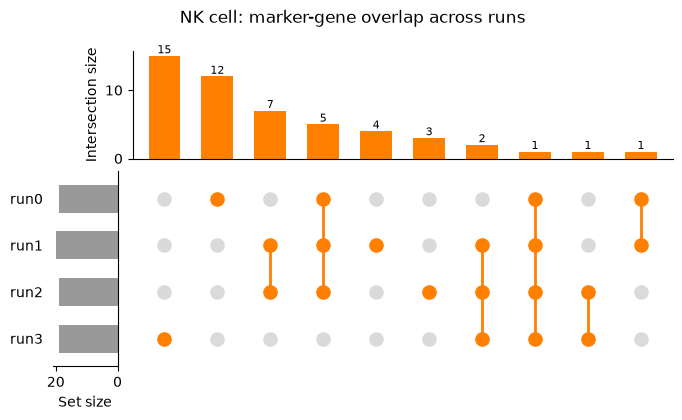

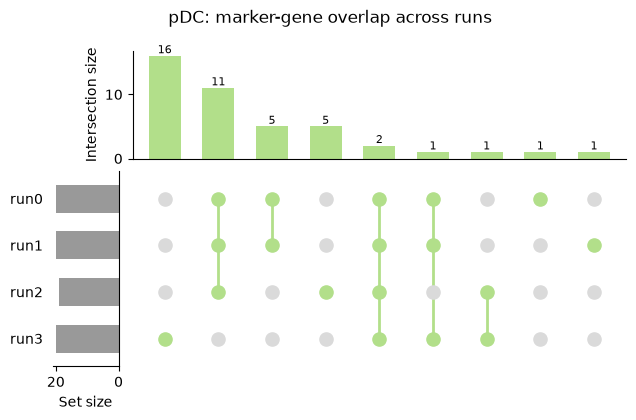

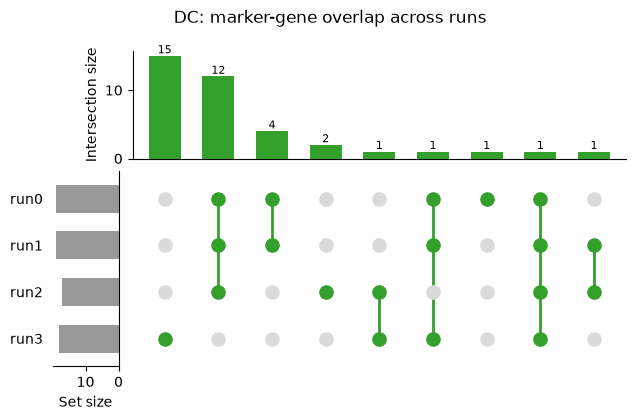

In [35]:
f1 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/10x-rep2-kallisto-cellbender-markers_fractions.tsv', sep = '\t')
f2 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/10x-rep1-kallisto-cellbender-markers_fractions.tsv', sep = '\t')
f3 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/bd-rhap-rep1-markers_fractions.tsv', sep = '\t')
f4 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/bd-rhap-rep2-markers_fractions.tsv', sep = '\t')
dfs = [f1,f2,f3, f4]
pairwise, summary = clusterwise_jaccard_stability(dfs)
plot_cluster_jaccard_boxplot(pairwise, pal)
figs = plot_all_cluster_upsets(dfs, pal)

In [2]:
import anndata as ad
ad1 = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep1/bd-rhap-rep1_with_markers.h5ad')
ad2 = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep2/bd-rhap-rep2_with_markers.h5ad')
ad3 = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/10x-rep1-kallisto-cellbender/10x-rep1-kallisto-cellbender_with_markers.h5ad')
ad4 = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/10x-rep2-kallisto-cellbender/10x-rep2-kallisto-cellbender_with_markers.h5ad')

ad1.obs['celltype_relabeled'] = ad1.obs['celltype_semi_manual'].map(mapper)
ad2.obs['celltype_relabeled'] = ad2.obs['celltype_semi_manual'].map(mapper)
ad3.obs['celltype_relabeled'] = ad3.obs['celltype_semi_manual'].map(mapper)
ad4.obs['celltype_relabeled'] = ad4.obs['celltype_semi_manual'].map(mapper)



list_of_adatas=[ad1, ad2, ad3, ad4]
dfs = adata_list_to_marker_dfs(list_of_adatas, groupby='celltype_relabeled', n_genes=20)
pairwise, summary = clusterwise_jaccard_stability(dfs)
plot_cluster_jaccard_boxplot(pairwise, pal)
figs = plot_all_cluster_upsets(dfs, pal)

PermissionError: [Errno 13] Permission denied: '/home/rzlin/og86asub'

In [2]:
ad.shape

NameError: name 'ad' is not defined